Accuracy: 0.83
Confusion Matrix:
 [[14  0  0]
 [ 0 11  3]
 [ 1  2  5]]
Classification Report:
               precision    recall  f1-score   support

     class_0       0.93      1.00      0.97        14
     class_1       0.85      0.79      0.81        14
     class_2       0.62      0.62      0.62         8

    accuracy                           0.83        36
   macro avg       0.80      0.80      0.80        36
weighted avg       0.83      0.83      0.83        36



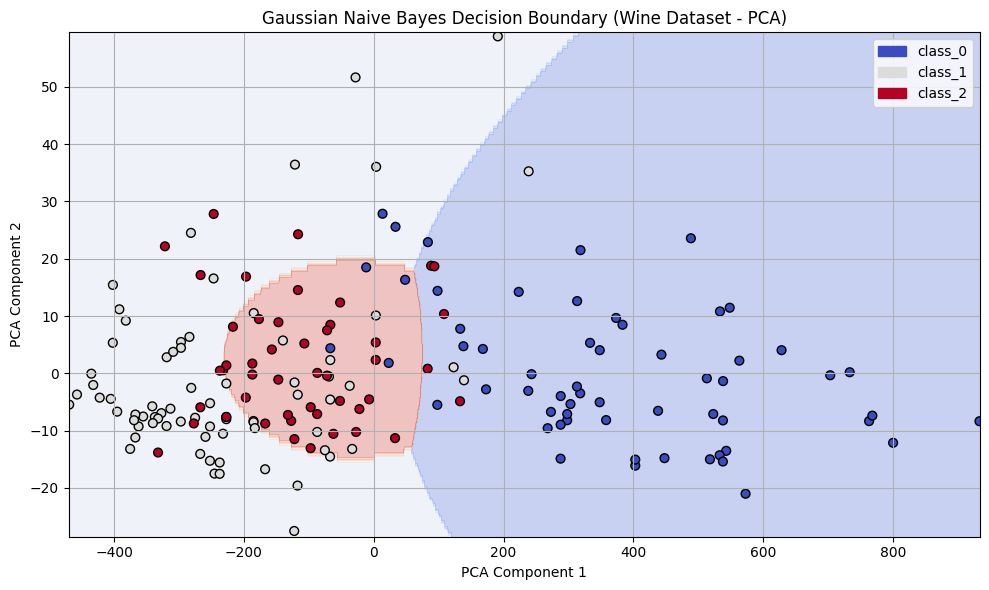

'Output -\nAccuracy: 0.83\nConfusion Matrix:\n [[14  0  0]\n [ 0 11  3]\n [ 1  2  5]]\nClassification Report:\n               precision    recall  f1-score   support\n     class_0       0.93      1.00      0.97        14\n     class_1       0.85      0.79      0.81        14\n     class_2       0.62      0.62      0.62         8\n    accuracy                           0.83        36\n   macro avg       0.80      0.80      0.80        36\nweighted avg       0.83      0.83      0.83        36\n'

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Load Wine dataset
wine = load_wine()
X, y = wine.data, wine.target
target_names = wine.target_names
# Reduce to 2D using PCA
X_pca = PCA(n_components=2).fit_transform(X)
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)
# Train Gaussian Naive Bayes
model = GaussianNB()
model.fit(X_train, y_train)
ypred = model.predict(X_test)
# Evaluate the model
accuracy = accuracy_score(y_test, ypred)
conf_matrix = confusion_matrix(y_test, ypred)
class_report = classification_report(y_test, ypred, target_names=target_names)
print(f"Accuracy: {accuracy:.2f}")
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)
# Create meshgrid for decision boundary
h = 1.0
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid).reshape(xx.shape)
# Plot decision boundary
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolor='k', s=40)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Gaussian Naive Bayes Decision Boundary (Wine Dataset - PCA)")
# Legend
patches = [mpatches.Patch(color=plt.cm.coolwarm(i / 2), label=target_names[i]) for i in np.unique(y)]
plt.legend(handles=patches)
plt.grid(True)
plt.tight_layout()
plt.show()
'''Output -
Accuracy: 0.83
Confusion Matrix:
 [[14  0  0]
 [ 0 11  3]
 [ 1  2  5]]
Classification Report:
               precision    recall  f1-score   support
     class_0       0.93      1.00      0.97        14
     class_1       0.85      0.79      0.81        14
     class_2       0.62      0.62      0.62         8
    accuracy                           0.83        36
   macro avg       0.80      0.80      0.80        36
weighted avg       0.83      0.83      0.83        36
'''